In [1]:
from pathlib import Path

import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

In [2]:
day = '21'
month = '06'
month_word = 'June'
year = '2014'

data_path = Path('./data')
image_dir = Path(f'./{year}{month}{day}')

df = pd.read_csv('../data/Prepared/cleaned_irradiance.csv')

image_list = sorted(image_dir.rglob('*.jpg'))[14:-28]

In [3]:
irradiance = []
images = []

for image_path in tqdm(image_list):
    irradiance_value = df[df['image_name'] == image_path.name]['irradiance'].values[0]

    irradiance.append(irradiance_value)
    images.append(image_path)

  0%|          | 0/840 [00:00<?, ?it/s]

100%|██████████| 840/840 [00:53<00:00, 15.64it/s]


In [4]:
predictions = irradiance + np.random.normal(scale=15, size=len(irradiance))

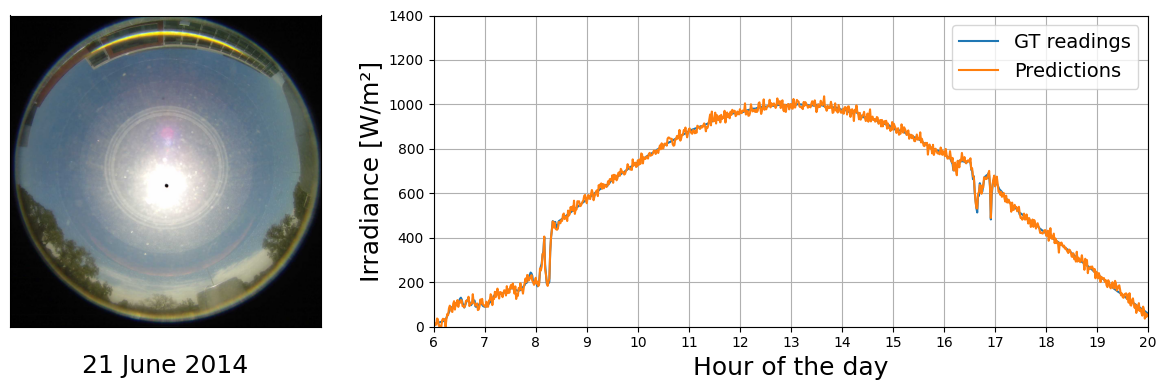

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 2]})

ax[0].imshow(np.asarray(Image.open(images[len(images)//2])))
ax[0].set_xticks([], [])
ax[0].set_yticks([], [])
ax[0].set_xlabel(f'{day} {month_word} {year}', fontsize=18, labelpad=20)

ax[1].plot(irradiance, label='GT readings')
ax[1].set_ylabel('Irradiance [W/m²]', fontsize=18)
ax[1].grid(True)
ax[1].set_ylim(0, 1400)
ax[1].set_xlim(0, len(irradiance))
ax[1].set_xticks(np.arange(0, len(irradiance)+1, 60), np.arange(6, 21, 1));
ax[1].set_xlabel('Hour of the day', fontsize=18)

prediction_lines_plotted = ax[1].plot(predictions, label='Predictions')

line_plotted = lines_plotted[0]
prediction_line_plotted = prediction_lines_plotted[0]

plt.legend(loc='upper right', fontsize=14)
plt.tight_layout()
plt.savefig('irradiance_prediction.png', dpi=300)

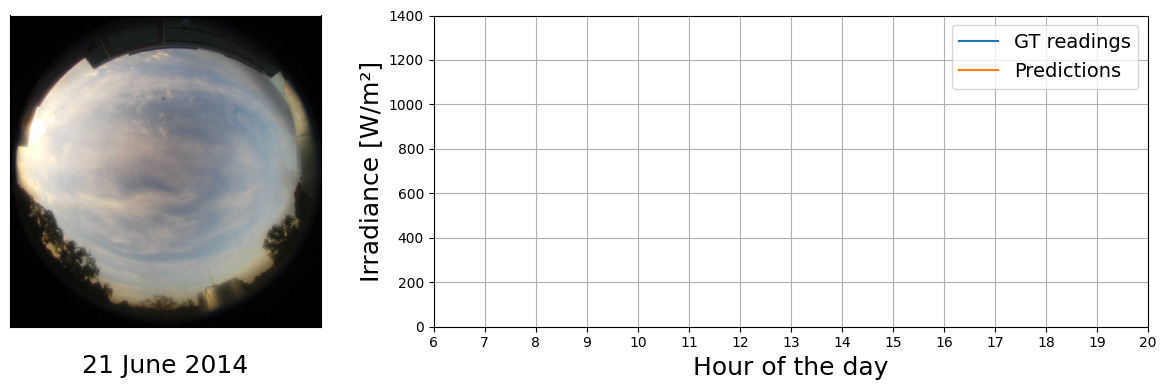

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 2]})

images_plotted = ax[0].imshow(np.asarray(Image.open(images[0])))
ax[0].set_xticks([], [])
ax[0].set_yticks([], [])
ax[0].set_xlabel(f'{day} {month_word} {year}', fontsize=18, labelpad=20)

lines_plotted = ax[1].plot([], label='GT readings')
ax[1].set_ylabel('Irradiance [W/m²]', fontsize=18)
ax[1].grid(True)
ax[1].set_ylim(0, 1400)
ax[1].set_xlim(0, len(irradiance))
ax[1].set_xticks(np.arange(0, len(irradiance)+1, 60), np.arange(6, 21, 1));
ax[1].set_xlabel('Hour of the day', fontsize=18)

prediction_lines_plotted = ax[1].plot([], label='Predictions')

line_plotted = lines_plotted[0]
prediction_line_plotted = prediction_lines_plotted[0]

plt.legend(loc='upper right', fontsize=14)
plt.tight_layout()

factor = 6


def animate(i):
    images_plotted.set_array(np.asarray(Image.open(images[i*factor])))
    line_plotted.set_data((np.arange(i*factor), irradiance[:i*factor]))
    prediction_line_plotted.set_data((np.arange(i*factor), predictions[:i*factor]))
    return images_plotted, line_plotted, prediction_line_plotted


ani = animation.FuncAnimation(fig, animate, repeat=True, frames=len(irradiance)//factor, interval=50)

# To save the animation using Pillow as a gif
writer = animation.PillowWriter(fps=60, metadata=dict(artist='Me'), bitrate=50000)
ani.save(f'{day}_{month}_{year}_Folsom.gif', writer=writer)

# plt.show()